In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

os.environ["KERAS_BACKEND"] = "torch"
os.environ["CUDA_VISIBLE_DEVICES"] = ""
import keras
import matplotlib.pyplot as plt
from training.datasets import load_dataset
from tqdm.auto import tqdm
from models.analytical import MultiOccupationMultiIsotope
import numpy as np

plt.style.use("latex.mplstyle")

In [40]:
data = np.array(
    [
        4.57020506e-02,
        1.95302553e-04,
        2.15528637e-02,
        6.33705119e-02,
        4.26330016e-05,
        6.56533739e-02,
        1.03788127e-02,
        2.98493504e-02,
        4.32893774e-02,
        5.77945278e-02,
        5.32343730e-02,
        7.19905312e-02,
    ]
)
momi = MultiOccupationMultiIsotope(fixed=True)
momi.t_final = 1

In [35]:
model = keras.models.load_model("trained_models/MOMI_fixed.keras")

In [19]:
for i in tqdm(range(10)):
    x, y = momi.training_data(include_params=False, n_eval=100, log_t_eval=True)
    y *= momi.correction_factors()
    iv = x[0, 1:]
    predictions = model.predict(x, verbose=0)
    max_ae = np.max(np.abs(predictions - y))
    if worst_max_ae is None or max_ae > worst_max_ae:
        print(f"New worst AE: {max_ae}")
        worst_max_ae = max_ae
        worst_iv = iv

  0%|          | 0/10 [00:00<?, ?it/s]

New worst AE: 0.5470943450927734


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 244ms/step


/home/bergerdd/TrapDiffusion/models/analytical/trap_diffusion.py:258: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.legend(loc="center right")
/home/bergerdd/TrapDiffusion/models/analytical/trap_diffusion.py:265: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.ylabel(f"Absolute Error {self.y_unit}")


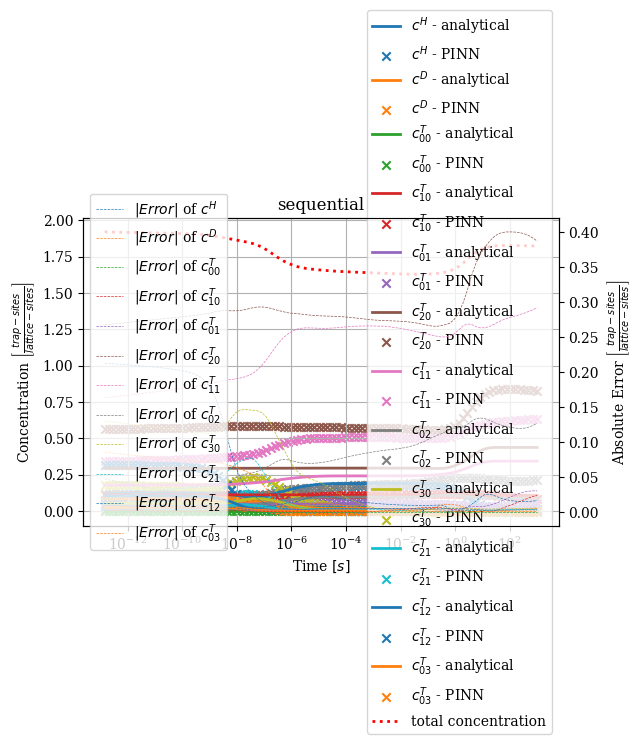

In [39]:
momi.evaluate(
    model, include_params=True, n_eval=100, log_t_eval=True, initial_values=data[:-9]
)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 233ms/step


/tmp/ipykernel_3014153/1478799548.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


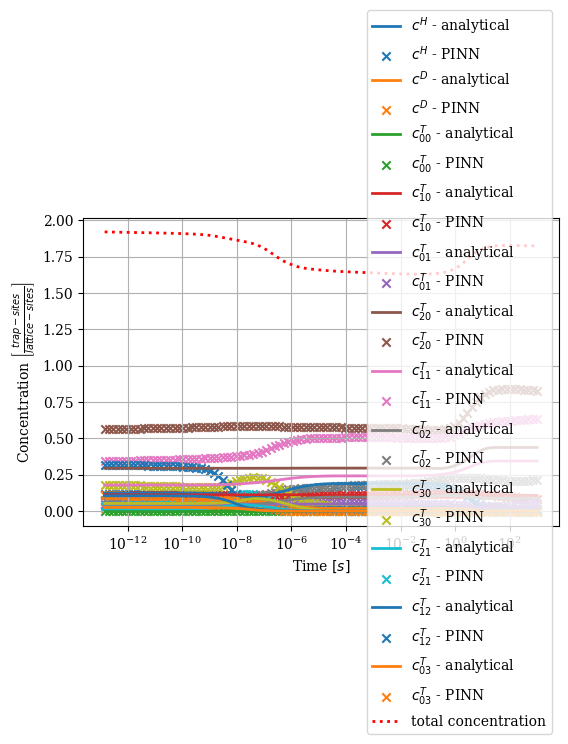

In [37]:
inputs, targets = momi.training_data(
    include_params=True, n_eval=100, log_t_eval=True, initial_values=data[:-9]
)
predictions = model.predict(inputs)
predictions = momi.targets_reverse_transform(predictions)
targets = momi.targets_reverse_transform(targets)
inputs = momi.inputs_reverse_transform(inputs)
corrections = momi.correction_factors()
predictions *= corrections
targets *= corrections
ts = inputs[:, 0]
for index, description in momi.vector_description.items():
    p = plt.plot(
        ts,
        targets[:, index],
        label=f"{description} - analytical",
        linewidth=2,
    )
    color = p[0].get_color()
    plt.scatter(
        ts,
        predictions[:, index],
        label=f"{description} - PINN",
        color=color,
        marker="x",
    )
plt.ylabel(f"Concentration {momi.y_unit}")
plt.xlabel(momi.xlabel)
plt.xscale(momi.xscale)
momi.plot_total(ts, predictions.T)
plt.legend(loc="center right")
plt.grid()
plt.tight_layout()